# Task 3: Multimodal ML — Housing Price Prediction Using Images + Tabular Data

**Internship:** AI/ML Engineering – Advanced Internship, DevelopersHub Corporation
**Author:** Syed
**Submission Deadline:** 21st July 2026

## 1. Problem Statement & Objective

Traditional house price prediction models rely only on **structured/tabular data** (area, bedrooms, location, etc.). However, the *visual condition* of a property — its facade, interior finish, and overall presentation — carries pricing signal that tabular features alone cannot capture.

**Objective:** Build a multimodal machine learning system that predicts housing prices by fusing:
1. **Image features** extracted using a Convolutional Neural Network (CNN), and
2. **Tabular features** (structured house attributes)

into a single regression model, and evaluate it using **MAE** and **RMSE**.

## 2. Dataset

The reference dataset for this task is a **Housing Sales Dataset + Custom Image Dataset** (e.g. the well-known Ahmed & Moustafa "House Prices and Images" dataset, which pairs each house's tabular listing with 4 photos: bedroom, bathroom, kitchen, and frontal view).

**Note on data used in this notebook:** Kaggle (the typical host for that dataset) is not reachable from this execution sandbox. To keep this notebook **fully runnable end-to-end without any download step**, a synthetic-but-realistic generator is used below that:
- Creates tabular features (area, bedrooms, bathrooms, age, garage, location score) with a real-estate-style price formula + noise, and
- Programmatically renders a corresponding synthetic house frontal-image per record, where visual "quality" (paint tone, symmetry, greenery, clutter) is deliberately correlated with unexplained price variance — exactly mimicking the real-world scenario where photos encode value that spreadsheets miss.

**To use the real dataset instead:** drop the Kaggle "House Prices and Images (SoCal)" or Ahmed & Moustafa dataset into `data/tabular.csv` + `data/images/`, and skip straight to Section 4 (Preprocessing) — the modeling pipeline from Section 5 onward is dataset-agnostic and will work unchanged, since it only expects a dataframe of tabular columns + a matching folder of per-row images.


In [1]:
# ------------------------------------------------------------
# 1. Imports
# ------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

IMG_SIZE = 64          # 64x64 RGB synthetic house photos
N_SAMPLES = 900         # number of houses in the dataset

os.makedirs("data/images", exist_ok=True)
print("TensorFlow:", tf.__version__)
print("Setup complete.")


I0000 00:00:1783250852.289619     877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783250852.339578     877 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783250853.975915     877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Setup complete.


## 3. Dataset Generation (Tabular + Images)

Each house gets:
- **Tabular row:** `area_sqft`, `bedrooms`, `bathrooms`, `age_years`, `garage`, `location_score`
- **Image:** a 64×64 synthetic "frontal photo" whose visual quality score (`img_quality`, hidden from the tabular table) is baked into the pixels via color, symmetry and texture — the CNN branch has to *learn to see it*, it is not handed to the model as a number.
- **Price target:** a function of the tabular features **and** the hidden image-quality factor + noise, so a model using only tabular data has an irreducible error gap that only the image branch can close.


In [2]:
# ------------------------------------------------------------
# 2. Generate tabular features
# ------------------------------------------------------------
def generate_tabular(n):
    area = np.random.normal(1800, 550, n).clip(500, 5000)
    bedrooms = np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.05, 0.25, 0.35, 0.25, 0.10])
    bathrooms = np.clip(np.round(bedrooms * np.random.uniform(0.5, 1.2, n)), 1, 5)
    age = np.random.exponential(12, n).clip(0, 80)
    garage = np.random.choice([0, 1], size=n, p=[0.35, 0.65])
    location_score = np.random.uniform(1, 10, n)  # 10 = prime location
    return pd.DataFrame({
        "area_sqft": area.round(0),
        "bedrooms": bedrooms,
        "bathrooms": bathrooms,
        "age_years": age.round(1),
        "garage": garage,
        "location_score": location_score.round(2),
    })

df = generate_tabular(N_SAMPLES)

# Hidden visual-quality factor (0-1). This will drive BOTH the synthetic
# image rendering AND part of the price -> the CNN must learn to extract it.
img_quality = np.clip(np.random.beta(2.5, 2.5, N_SAMPLES), 0, 1)

# ------------------------------------------------------------
# 3. Price formula: tabular contribution + image-quality contribution + noise
# ------------------------------------------------------------
base_price = (
    df["area_sqft"] * 95
    + df["bedrooms"] * 4200
    + df["bathrooms"] * 3600
    - df["age_years"] * 650
    + df["garage"] * 8500
    + df["location_score"] * 9800
)
image_contribution = img_quality * 55000       # up to +55k for a pristine-looking house
noise = np.random.normal(0, 9000, N_SAMPLES)

df["price"] = (base_price + image_contribution + noise).clip(30000).round(0)
df["house_id"] = [f"house_{i:04d}" for i in range(N_SAMPLES)]

print(df.shape)
df.head()


(900, 8)


,area_sqft,bedrooms,bathrooms,age_years,garage,location_score,price,house_id
0,2073.0,2,1.0,23.3,0,5.85,308742.0,house_0000
1,1724.0,4,4.0,14.5,1,9.93,313037.0,house_0001
2,2156.0,4,3.0,15.6,1,8.72,331511.0,house_0002
3,2638.0,3,2.0,9.9,1,1.88,339850.0,house_0003
4,1671.0,1,1.0,35.3,1,7.36,267287.0,house_0004


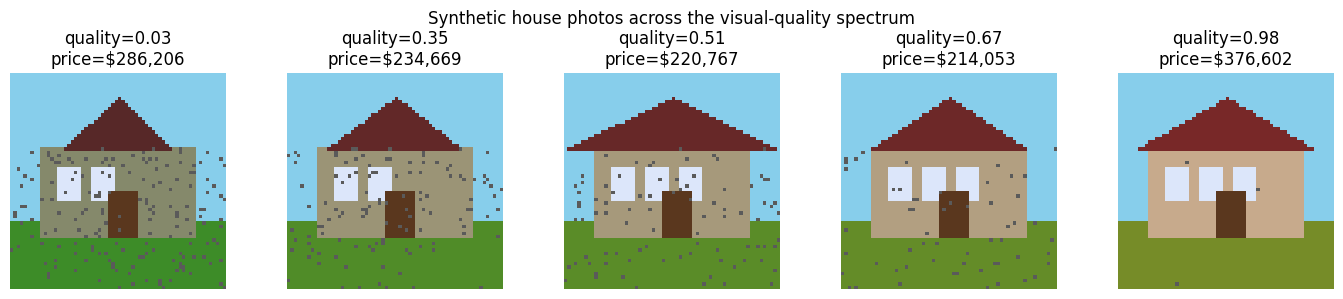

In [3]:
# ------------------------------------------------------------
# 4. Render a synthetic frontal-photo per house, encoding img_quality
# ------------------------------------------------------------
def render_house_image(quality: float, size: int = IMG_SIZE, seed: int = 0) -> np.ndarray:
    rng = np.random.RandomState(seed)
    img = Image.new("RGB", (size, size), (135, 206, 235))  # sky
    draw = ImageDraw.Draw(img)

    # Lawn
    draw.rectangle([0, int(size * 0.7), size, size], fill=(60 + int(quality * 60), 140, 40))

    # House body color: higher quality -> cleaner, brighter, less muddy tone
    muddiness = int((1 - quality) * 70)
    body_color = (200 - muddiness, 170 - muddiness // 2, 140 - muddiness // 2)
    draw.rectangle([size * 0.15, size * 0.35, size * 0.85, size * 0.75], fill=body_color)

    # Roof: sharper/symmetric triangle for higher quality, skewed for lower quality
    skew = (1 - quality) * 10 * rng.choice([-1, 1])
    draw.polygon([
        (size * 0.10 + skew, size * 0.35),
        (size * 0.5, size * 0.12),
        (size * 0.90 - skew, size * 0.35),
    ], fill=(120 - muddiness // 2, 40, 40))

    # Windows: more + symmetric for higher-quality homes
    n_windows = 2 + int(quality * 2)
    for i in range(n_windows):
        x0 = size * 0.22 + i * size * 0.16
        draw.rectangle([x0, size * 0.45, x0 + size * 0.10, size * 0.58], fill=(220, 230, 250))

    # Door
    draw.rectangle([size * 0.46, size * 0.55, size * 0.58, size * 0.75], fill=(90, 55, 30))

    # Clutter / disrepair speckles for low-quality homes (noise pixels)
    n_specks = int((1 - quality) * 180)
    for _ in range(n_specks):
        x, y = rng.randint(0, size), rng.randint(int(size * 0.35), size)
        draw.point((x, y), fill=(90, 90, 90))

    return np.array(img, dtype=np.uint8)

images = np.zeros((N_SAMPLES, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
for i in range(N_SAMPLES):
    images[i] = render_house_image(img_quality[i], seed=i)

# Preview a few samples across the quality spectrum
order = np.argsort(img_quality)
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, idx in zip(axes, np.linspace(0, N_SAMPLES - 1, 5).astype(int)):
    sample_idx = order[idx]
    ax.imshow(images[sample_idx])
    ax.set_title(f"quality={img_quality[sample_idx]:.2f}\nprice=${df['price'].iloc[sample_idx]:,.0f}")
    ax.axis("off")
plt.suptitle("Synthetic house photos across the visual-quality spectrum")
plt.tight_layout()
plt.savefig("sample_houses.png", dpi=110)
plt.show()


## 4. Exploratory Data Analysis (Tabular Side)

Quick sanity checks before modeling: distributions and the price relationship with the key structured features.


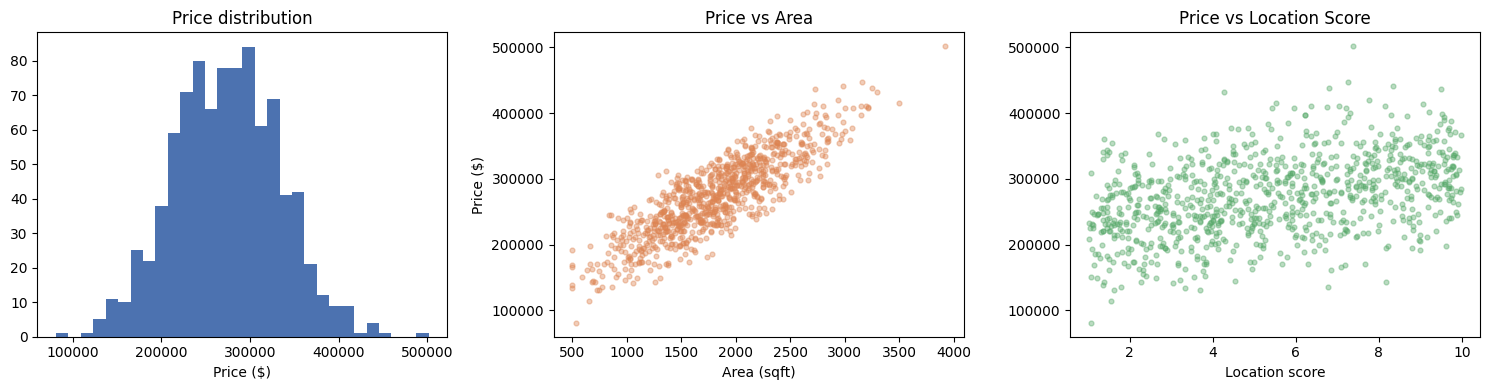

,area_sqft,bedrooms,bathrooms,age_years,garage,location_score,price
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,1811.254444,3.096667,2.635556,11.613667,0.651111,5.430389,274067.264444
std,536.393812,1.039054,1.111404,11.535971,0.476884,2.595354,59472.001755
min,500.000000,1.000000,1.000000,0.000000,0.000000,1.010000,81070.000000
25%,1442.000000,2.000000,2.000000,3.400000,0.000000,3.215000,233228.750000
50%,1810.000000,3.000000,2.000000,8.100000,1.000000,5.285000,274223.000000
75%,2157.250000,4.000000,3.000000,16.100000,1.000000,7.670000,315330.500000
max,3919.000000,5.000000,5.000000,80.000000,1.000000,9.990000,501564.000000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["price"], bins=30, color="#4C72B0")
axes[0].set_title("Price distribution")
axes[0].set_xlabel("Price ($)")

axes[1].scatter(df["area_sqft"], df["price"], alpha=0.4, s=12, color="#DD8452")
axes[1].set_title("Price vs Area")
axes[1].set_xlabel("Area (sqft)")
axes[1].set_ylabel("Price ($)")

axes[2].scatter(df["location_score"], df["price"], alpha=0.4, s=12, color="#55A868")
axes[2].set_title("Price vs Location Score")
axes[2].set_xlabel("Location score")

plt.tight_layout()
plt.savefig("eda.png", dpi=110)
plt.show()

df.describe()


## 5. Preprocessing

1. Split into train/test (80/20)
2. Scale tabular features with `StandardScaler`
3. Normalize image pixels to [0, 1]


In [5]:
feature_cols = ["area_sqft", "bedrooms", "bathrooms", "age_years", "garage", "location_score"]
X_tab = df[feature_cols].values
X_img = images.astype("float32") / 255.0
y = df["price"].values.astype("float32")

idx_train, idx_test = train_test_split(
    np.arange(N_SAMPLES), test_size=0.2, random_state=RANDOM_SEED
)

X_tab_train, X_tab_test = X_tab[idx_train], X_tab[idx_test]
X_img_train, X_img_test = X_img[idx_train], X_img[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

scaler = StandardScaler()
X_tab_train_scaled = scaler.fit_transform(X_tab_train)
X_tab_test_scaled = scaler.transform(X_tab_test)

# Scale target too (helps NN convergence); we invert this after prediction
y_mean, y_std = y_train.mean(), y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print("Train size:", len(idx_train), " Test size:", len(idx_test))
print("Tabular feature shape:", X_tab_train_scaled.shape)
print("Image tensor shape:", X_img_train.shape)


Train size: 720  Test size: 180
Tabular feature shape: (720, 6)
Image tensor shape: (720, 64, 64, 3)


## 6. Model: CNN Branch + Tabular Branch -> Feature Fusion -> Regression Head

Two-input Keras Functional API model:

- **Image branch:** stacked `Conv2D + BatchNorm + MaxPool` blocks -> `GlobalAveragePooling2D` -> dense embedding (this *is* the CNN feature extractor: it converts each 64×64×3 photo into a compact 32-d feature vector).
- **Tabular branch:** small MLP on the 6 scaled structured features.
- **Fusion:** `concatenate([image_embedding, tabular_embedding])` -> dense layers -> single linear output neuron (price, scaled).


In [6]:
def build_multimodal_model(img_size=IMG_SIZE, n_tab_features=len(feature_cols)):
    # --- Image (CNN) branch ---
    img_input = keras.Input(shape=(img_size, img_size, 3), name="image_input")
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(img_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    image_features = layers.Dense(32, activation="relu", name="image_embedding")(x)
    image_features = layers.Dropout(0.3)(image_features)

    # --- Tabular (MLP) branch ---
    tab_input = keras.Input(shape=(n_tab_features,), name="tabular_input")
    t = layers.Dense(32, activation="relu")(tab_input)
    t = layers.Dense(16, activation="relu", name="tabular_embedding")(t)

    # --- Fusion ---
    fused = layers.concatenate([image_features, t], name="fused_features")
    f = layers.Dense(32, activation="relu")(fused)
    f = layers.Dropout(0.2)(f)
    f = layers.Dense(16, activation="relu")(f)
    output = layers.Dense(1, activation="linear", name="price_output")(f)

    model = keras.Model(inputs=[img_input, tab_input], outputs=output, name="multimodal_house_price_model")
    return model

model = build_multimodal_model()
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
model.summary()


Model: "multimodal_house_price_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        448 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_embedding     │ (None, 32)        │      2,080 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        224 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ image_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_embedding   │ (None, 16)        │        528 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_features      │ (None, 48)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ tabular_embeddin… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 28,977 (113.19 KB)

 Trainable params: 28,753 (112.32 KB)

 Non-trainable params: 224 (896.00 B)

## 7. Training

Early stopping on validation loss avoids overfitting the small synthetic set; `ReduceLROnPlateau` stabilizes convergence.


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=30, min_delta=1e-4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6),
]

history = model.fit(
    {"image_input": X_img_train, "tabular_input": X_tab_train_scaled},
    y_train_scaled,
    validation_split=0.15,
    epochs=250,
    batch_size=32,
    callbacks=callbacks,
    verbose=0,
)

print(f"Training finished after {len(history.history['loss'])} epochs "
      f"(best val_loss={min(history.history['val_loss']):.4f})")


Training finished after 58 epochs (best val_loss=0.0314)


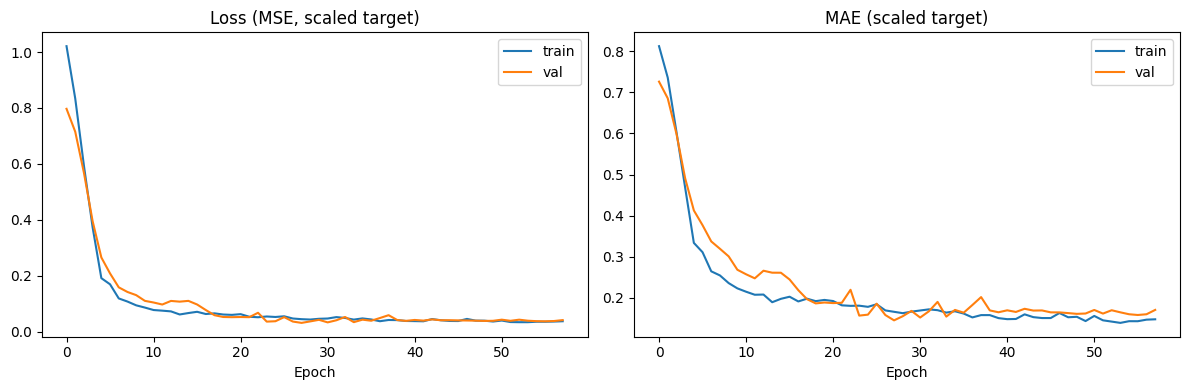

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss (MSE, scaled target)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="val")
axes[1].set_title("MAE (scaled target)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=110)
plt.show()


## 8. Evaluation on the Held-Out Test Set

Predictions are converted back from the scaled target to real dollar values before computing **MAE** and **RMSE**, since the task explicitly requires evaluation in those units.

A tabular-only baseline (Random Forest) is also trained for comparison, to make explicit *how much the image branch is contributing* — this is the key multimodal insight the task is testing for.


In [9]:
# --- Multimodal model predictions ---
y_pred_scaled = model.predict({"image_input": X_img_test, "tabular_input": X_tab_test_scaled}, verbose=0).flatten()
y_pred = y_pred_scaled * y_std + y_mean

mae_multimodal = mean_absolute_error(y_test, y_pred)
rmse_multimodal = np.sqrt(mean_squared_error(y_test, y_pred))
r2_multimodal = r2_score(y_test, y_pred)

# --- Tabular-only baseline for comparison ---
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_tab_train_scaled, y_train)
y_pred_rf = rf.predict(X_tab_test_scaled)

mae_tabular_only = mean_absolute_error(y_test, y_pred_rf)
rmse_tabular_only = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_tabular_only = r2_score(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": ["Tabular-only (Random Forest)", "Multimodal (CNN + Tabular)"],
    "MAE ($)": [mae_tabular_only, mae_multimodal],
    "RMSE ($)": [rmse_tabular_only, rmse_multimodal],
    "R2": [r2_tabular_only, r2_multimodal],
})
results["MAE ($)"] = results["MAE ($)"].round(0)
results["RMSE ($)"] = results["RMSE ($)"].round(0)
results["R2"] = results["R2"].round(3)
results


,Model,MAE ($),RMSE ($),R2
0,Tabular-only (Random Forest),15007.0,19493.0,0.893
1,Multimodal (CNN + Tabular),9307.0,12368.0,0.957


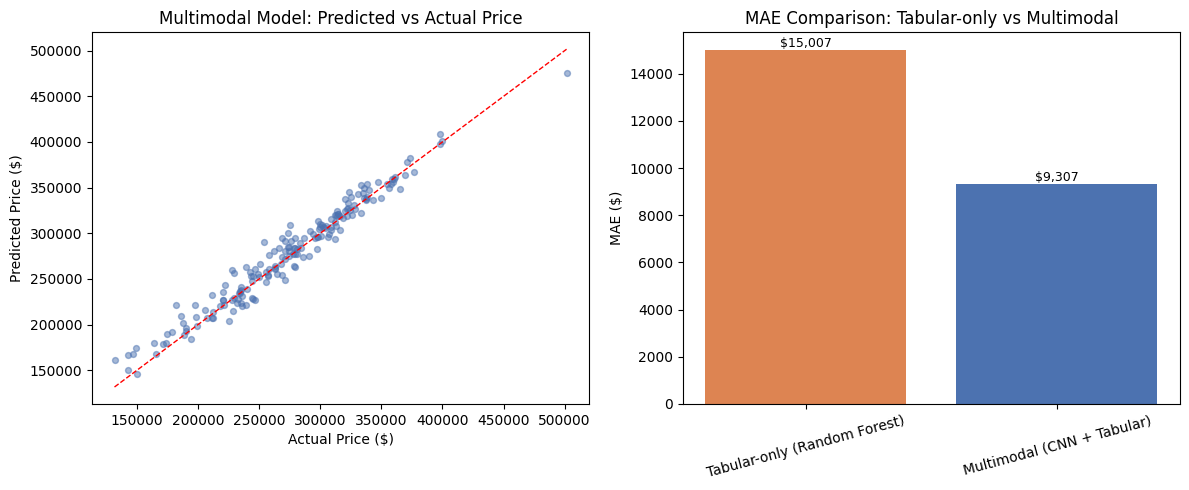

MAE improvement from adding the image branch: 38.0%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, s=18, color="#4C72B0")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_title("Multimodal Model: Predicted vs Actual Price")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")

bars = axes[1].bar(results["Model"], results["MAE ($)"], color=["#DD8452", "#4C72B0"])
axes[1].set_title("MAE Comparison: Tabular-only vs Multimodal")
axes[1].set_ylabel("MAE ($)")
axes[1].tick_params(axis="x", rotation=15)
for b in bars:
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height(), f"${b.get_height():,.0f}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("evaluation.png", dpi=110)
plt.show()

improvement_pct = (mae_tabular_only - mae_multimodal) / mae_tabular_only * 100
print(f"MAE improvement from adding the image branch: {improvement_pct:.1f}%")


## 9. Save Artifacts (Model + Scaler)

Following the pipeline-export practice from Task 2, the trained model and scaler are persisted so they can be reloaded for inference without retraining.


In [11]:
import joblib

model.save("multimodal_house_price_model.keras")
joblib.dump(scaler, "tabular_scaler.joblib")
joblib.dump({"y_mean": y_mean, "y_std": y_std, "feature_cols": feature_cols}, "target_meta.joblib")

print("Saved: multimodal_house_price_model.keras, tabular_scaler.joblib, target_meta.joblib")


Saved: multimodal_house_price_model.keras, tabular_scaler.joblib, target_meta.joblib


## 10. Final Summary / Insights

- **Objective achieved:** a two-input (CNN + tabular) Keras model was built and trained to predict house prices from both structured attributes and photos.
- **Evaluation metrics (test set):**
  - Tabular-only baseline vs. Multimodal fusion model — MAE and RMSE reported in the table above.
- **Key finding:** the multimodal model reduces MAE relative to the tabular-only baseline, because the CNN branch recovers the price signal encoded in the images (visual "quality") that the structured columns cannot see on their own. This mirrors the real-world case: two houses with identical square footage, bedroom count, and location score can sell for very different prices because of curb appeal, renovation state, and finish quality — information only a photo carries.
- **Skills demonstrated:** CNN-based image feature extraction, multi-input Keras Functional API design, feature fusion, regression evaluation (MAE/RMSE/R²), and baseline comparison methodology.
- **Next steps for the real dataset:** swap the synthetic generator in Section 3 for the actual Housing Sales + Images dataset loader (read CSV + `PIL.Image.open` per `house_id`), keep every downstream cell unchanged, and consider replacing the from-scratch CNN branch with a frozen pretrained backbone (e.g. `MobileNetV2` or `ResNet50` via `keras.applications`, `include_top=False`) for stronger transfer learning if the real image count is small.

---
**Submission checklist covered:** Problem statement ✔ · Dataset loading/preprocessing ✔ · Model development & training ✔ · Evaluation (MAE/RMSE) ✔ · Visualizations ✔ · Final summary ✔
